# Nestedness Visualization - Advanced Node Filtering Strategies

This notebook implements different filtering strategies to better visualize nestedness patterns in bipartite VC networks.

**Key Insight**: Nestedness is about WHO connects to WHOM, not just degree distribution.
- **Generalists**: High-degree nodes (hubs) that connect to many others
- **Specialists**: Low-degree nodes that connect ONLY to generalists

This is the core pattern of nestedness!

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
import seaborn as sns
from matplotlib.lines import Line2D

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

In [2]:
# Load the data
nodes_df = pd.read_csv('../data/processed/us/nodes.csv')
edges_df = pd.read_csv('../data/processed/us/edges.csv')

print(f"Nodes shape: {nodes_df.shape}")
print(f"Edges shape: {edges_df.shape}")
print(f"\nNumber of unique communities: {nodes_df['community_id'].nunique()}")

Nodes shape: (15347, 7)
Edges shape: (156481, 24)

Number of unique communities: 171


In [3]:
# Calculate degree for each node
source_degrees = edges_df['Source'].value_counts()
target_degrees = edges_df['Target'].value_counts()
all_degrees = pd.concat([source_degrees, target_degrees]).groupby(level=0).sum()

degree_df = pd.DataFrame({
    'node': all_degrees.index,
    'degree': all_degrees.values
})

# Merge with nodes
nodes_with_degree = nodes_df.merge(degree_df, on='node', how='left')
nodes_with_degree['degree'] = nodes_with_degree['degree'].fillna(0).astype(int)

print(f"Nodes with degree calculated: {len(nodes_with_degree)}")
print(f"Mean degree: {nodes_with_degree['degree'].mean():.2f}")
print(f"Max degree: {nodes_with_degree['degree'].max()}")

Nodes with degree calculated: 15347
Mean degree: 20.39
Max degree: 1436


In [4]:
# Visualization helper function
def create_bipartite_graph(nodes_subset, edges_subset, community_id, graph_type="Filtered"):
    """
    Create a bipartite graph visualization for a subset of nodes
    """
    G = nx.Graph()
    
    # Add nodes with bipartite set attribute
    for _, node_row in nodes_subset.iterrows():
        G.add_node(node_row['node'], 
                   bipartite=node_row['set'],
                   degree=node_row['degree'])
    
    # Add edges
    for _, edge_row in edges_subset.iterrows():
        if edge_row['Source'] in G.nodes() and edge_row['Target'] in G.nodes():
            G.add_edge(edge_row['Source'], edge_row['Target'])
    
    # Separate by bipartite sets
    set_0_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 0]
    set_1_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 1]
    
    if len(set_0_nodes) == 0 or len(set_1_nodes) == 0:
        print(f"Warning: Community {community_id} doesn't have nodes in both sets")
        return None
    
    # Sort nodes by degree (descending)
    set_0_nodes_sorted = sorted(set_0_nodes, key=lambda n: G.nodes[n].get('degree', 0), reverse=True)
    set_1_nodes_sorted = sorted(set_1_nodes, key=lambda n: G.nodes[n].get('degree', 0), reverse=True)
    
    # Create positions
    pos = {}
    y_spacing_0 = 2.0 / max(len(set_0_nodes_sorted), 1) if len(set_0_nodes_sorted) > 1 else 1
    for i, node in enumerate(set_0_nodes_sorted):
        pos[node] = (0, 1 - i * y_spacing_0)
    
    y_spacing_1 = 2.0 / max(len(set_1_nodes_sorted), 1) if len(set_1_nodes_sorted) > 1 else 1
    for i, node in enumerate(set_1_nodes_sorted):
        pos[node] = (2, 1 - i * y_spacing_1)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(20, 12))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, 
                          nodelist=set_0_nodes_sorted,
                          node_color='#3498db',
                          node_size=[G.nodes[node].get('degree', 1) * 50 for node in set_0_nodes_sorted],
                          alpha=0.8)
    
    nx.draw_networkx_nodes(G, pos,
                          nodelist=set_1_nodes_sorted,
                          node_color='#e74c3c',
                          node_size=[G.nodes[node].get('degree', 1) * 50 for node in set_1_nodes_sorted],
                          alpha=0.8)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=1.5, edge_color='gray')
    
    # Draw labels
    labels = {node: node.split('-')[0][:20] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
    
    plt.title(f'Community {community_id} - {graph_type}\n'
              f'Late-stage: {len(set_0_nodes_sorted)} nodes | Early-stage: {len(set_1_nodes_sorted)} nodes | '
              f'Edges: {G.number_of_edges()}',
              fontsize=16, fontweight='bold', pad=20)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Late-stage (Set 0)',
               markerfacecolor='#3498db', markersize=15, alpha=0.8),
        Line2D([0], [0], marker='o', color='w', label='Early-stage (Set 1)',
               markerfacecolor='#e74c3c', markersize=15, alpha=0.8)
    ]
    plt.legend(handles=legend_elements, loc='lower center', fontsize=12, framealpha=0.9)
    plt.axis('off')
    plt.tight_layout()
    
    return G

## Strategy 1: Generalist-Specialist Filtering (BEST for Nestedness)

This strategy directly targets the definition of nestedness:
- **Generalists**: Highest degree nodes from each set
- **Specialists**: Low-degree nodes that connect ONLY to generalists

This creates a clear visual "perfect" nested pattern.

In [5]:
def get_nestedness_revealing_nodes(df, community_id, edges_df, n_generalists=10, n_specialists=20):
    """
    Select nodes that best reveal nestedness structure:
    - Generalists: High-degree nodes (hubs)
    - Specialists: Low-degree nodes that ONLY connect to generalists
    
    This is the core pattern of nestedness!
    """
    community_nodes = df[df['community_id'] == community_id].copy()
    
    # Get generalists (highest degree nodes) from EACH set
    left_nodes = community_nodes[community_nodes['set'] == 0].sort_values('degree', ascending=False)
    right_nodes = community_nodes[community_nodes['set'] == 1].sort_values('degree', ascending=False)
    
    generalists_left = left_nodes.head(n_generalists)
    generalists_right = right_nodes.head(n_generalists)
    generalist_ids = set(generalists_left['node']).union(set(generalists_right['node']))
    
    # Find specialists: low-degree nodes that connect ONLY to generalists
    specialists = []
    
    for _, node_row in community_nodes.iterrows():
        node_id = node_row['node']
        if node_id in generalist_ids:
            continue  # Skip generalists
            
        # Get this node's connections
        node_edges = edges_df[
            (edges_df['Source'] == node_id) | (edges_df['Target'] == node_id)
        ]
        
        # Get connected nodes
        connected = set()
        connected.update(node_edges['Source'].values)
        connected.update(node_edges['Target'].values)
        connected.discard(node_id)  # Remove self
        
        # Check if ALL connections are to generalists
        if len(connected) > 0 and connected.issubset(generalist_ids):
            specialists.append({
                'node': node_id,
                'degree': node_row['degree'],
                'set': node_row['set'],
                'num_generalist_connections': len(connected)
            })
    
    # Sort specialists by degree and take top n_specialists
    specialists_df = pd.DataFrame(specialists).sort_values('degree', ascending=True).head(n_specialists)
    specialist_nodes = community_nodes[community_nodes['node'].isin(specialists_df['node'])]
    
    print(f"Community {community_id}: {len(generalists_left)} + {len(generalists_right)} generalists, "
          f"{len(specialist_nodes)} specialists (from {len(specialists)} candidates)")
    
    return pd.concat([generalists_left, generalists_right, specialist_nodes], ignore_index=True)

STRATEGY 1: GENERALIST-SPECIALIST FILTERING

Processing Community 0...
Community 0: 10 + 10 generalists, 20 specialists (from 20 candidates)
Selected 40 nodes with 182 edges
Set 0: 28, Set 1: 12
Community 0: 10 + 10 generalists, 20 specialists (from 20 candidates)
Selected 40 nodes with 182 edges
Set 0: 28, Set 1: 12


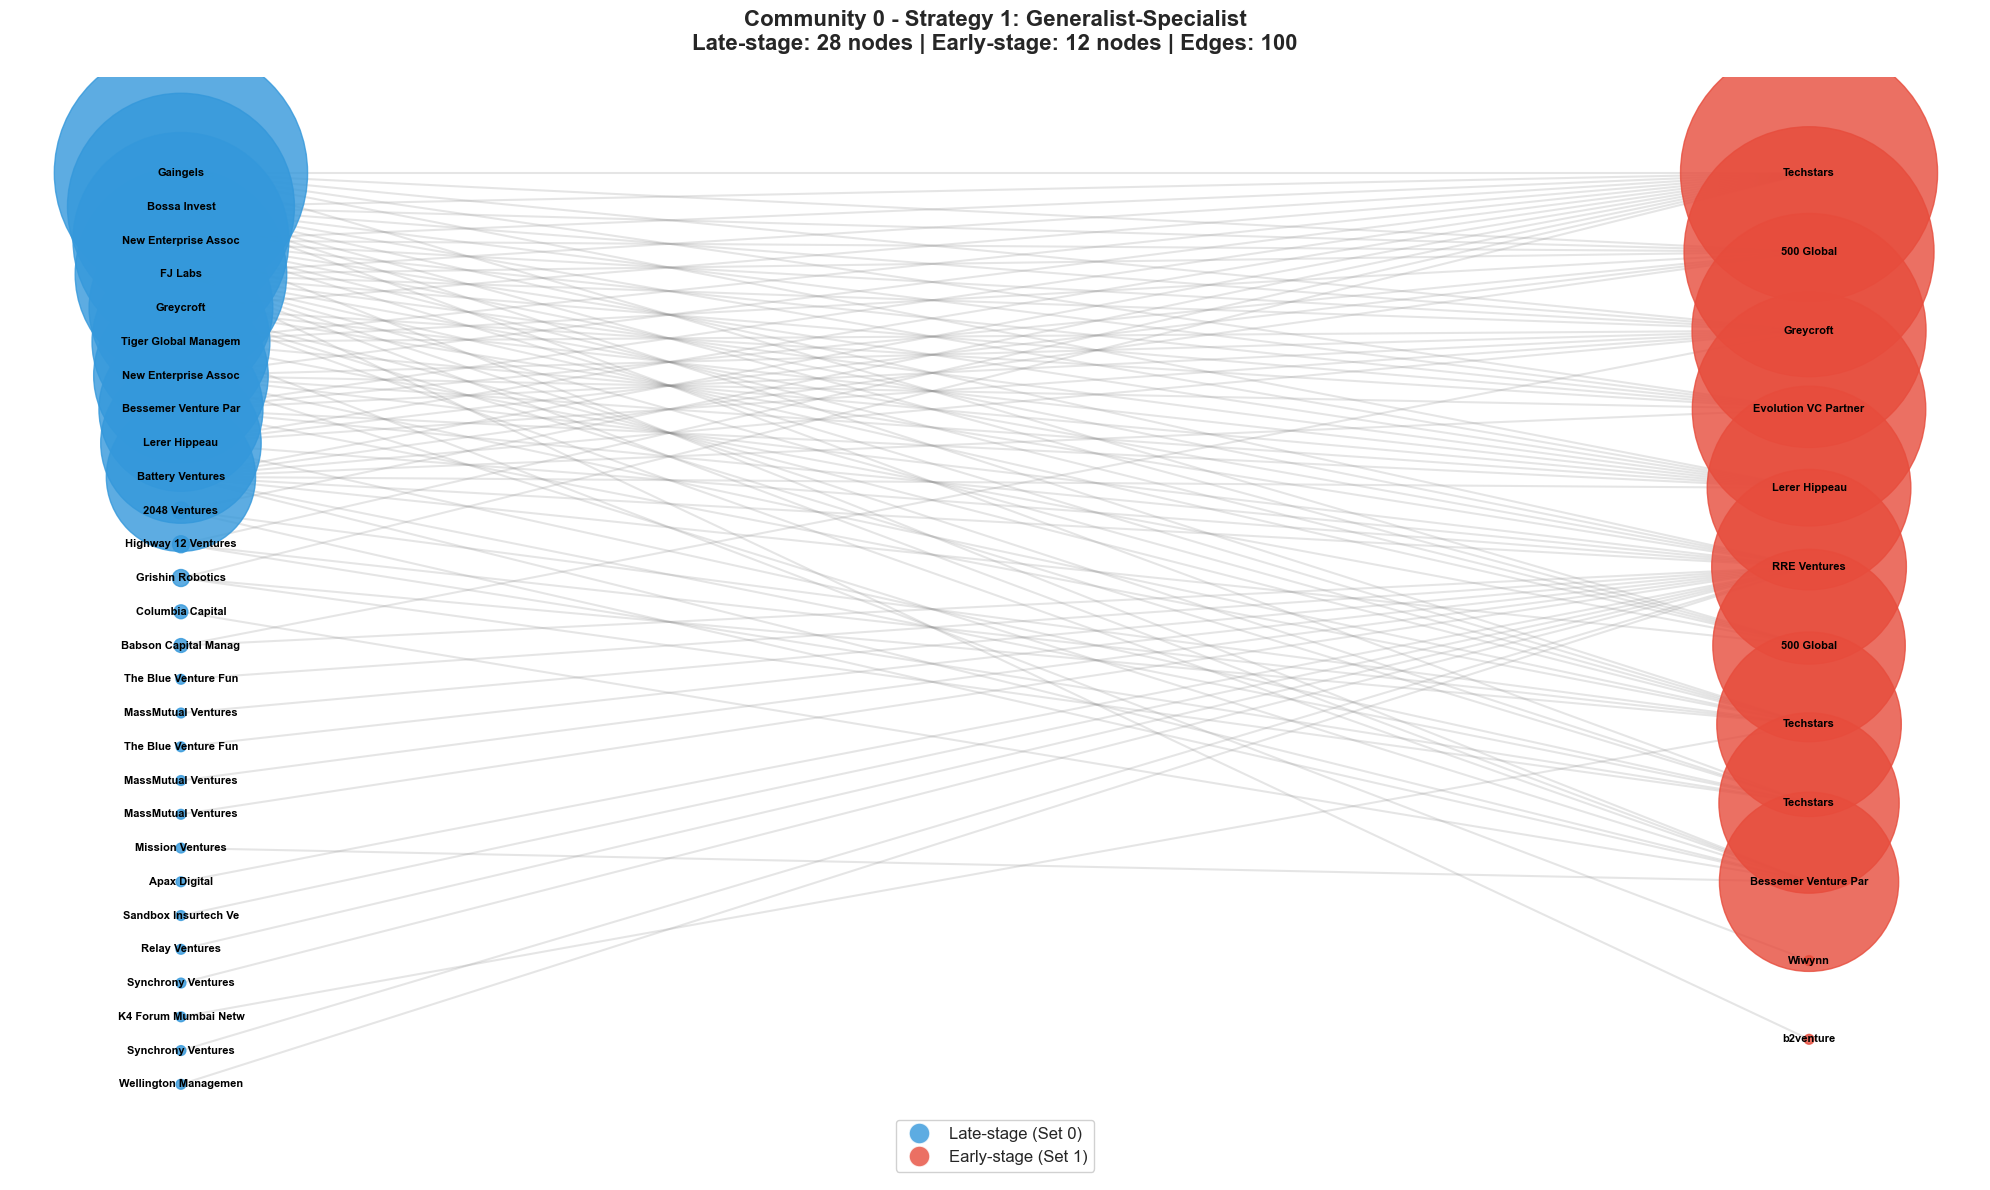



Processing Community 1...
Community 1: 10 + 10 generalists, 20 specialists (from 28 candidates)
Selected 40 nodes with 41 edges
Set 0: 24, Set 1: 16
Community 1: 10 + 10 generalists, 20 specialists (from 28 candidates)
Selected 40 nodes with 41 edges
Set 0: 24, Set 1: 16


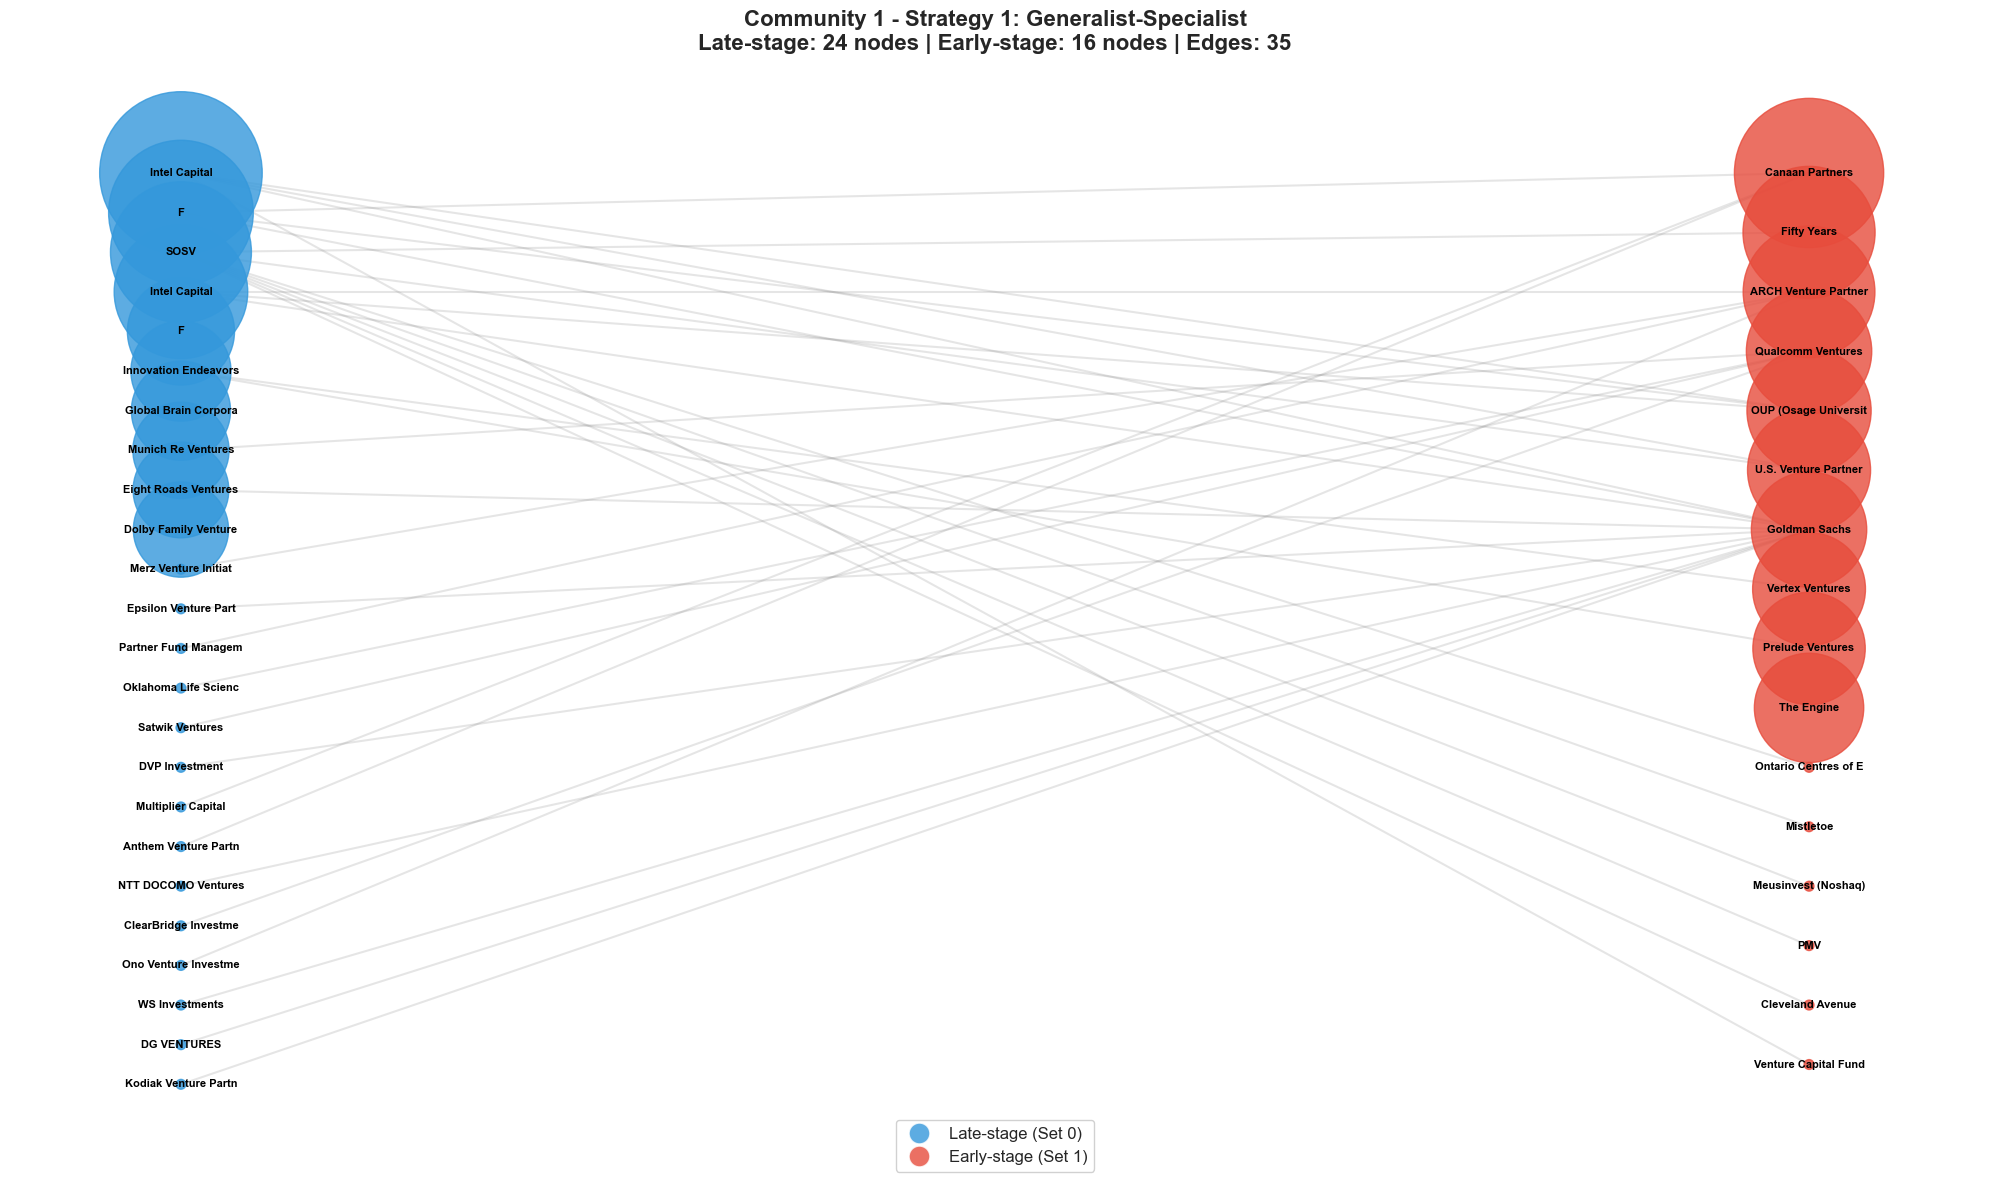



Processing Community 2...
Community 2: 10 + 10 generalists, 20 specialists (from 124 candidates)
Selected 40 nodes with 369 edges
Set 0: 30, Set 1: 10
Community 2: 10 + 10 generalists, 20 specialists (from 124 candidates)
Selected 40 nodes with 369 edges
Set 0: 30, Set 1: 10


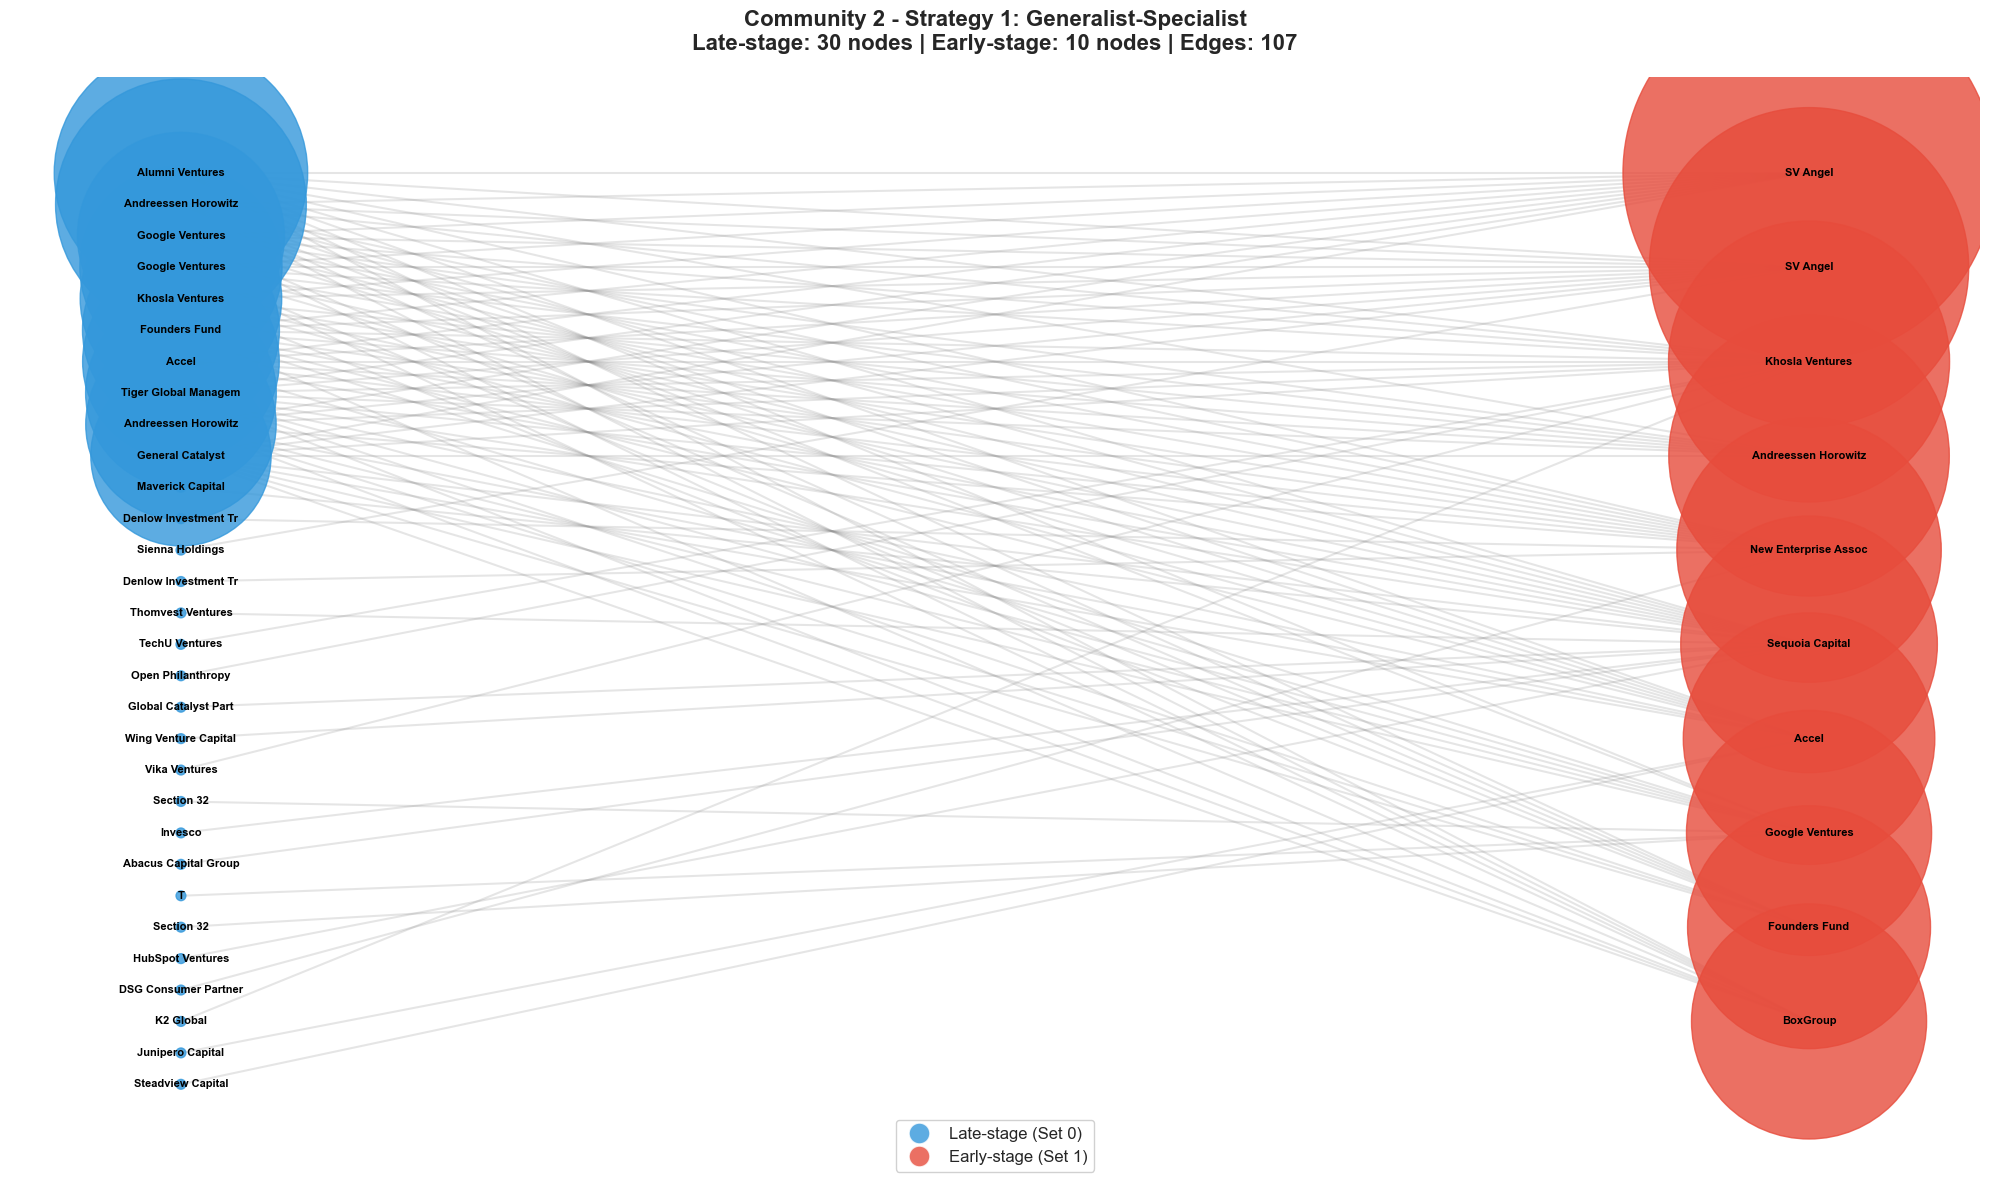

In [6]:
# Apply Strategy 1: Generalist-Specialist Filtering
target_communities = [0, 1, 2]

print("="*80)
print("STRATEGY 1: GENERALIST-SPECIALIST FILTERING")
print("="*80)

for community_id in target_communities:
    print(f"\nProcessing Community {community_id}...")
    
    # Get nodes using Strategy 1
    selected_nodes = get_nestedness_revealing_nodes(
        nodes_with_degree, community_id, edges_df, 
        n_generalists=10, n_specialists=20
    )
    
    # Get edges between selected nodes
    selected_node_ids = set(selected_nodes['node'].values)
    selected_edges = edges_df[
        (edges_df['Source'].isin(selected_node_ids)) & 
        (edges_df['Target'].isin(selected_node_ids))
    ]
    
    print(f"Selected {len(selected_nodes)} nodes with {len(selected_edges)} edges")
    print(f"Set 0: {(selected_nodes['set'] == 0).sum()}, Set 1: {(selected_nodes['set'] == 1).sum()}")
    
    # Create visualization
    g = create_bipartite_graph(selected_nodes, selected_edges, community_id, 
                               "Strategy 1: Generalist-Specialist")
    
    plt.show()
    print()

## Strategy 2: Degree-Ratio Filtering

Select nodes with different degree ratios to show nestedness gradient:
- High degree: Core generalists
- Medium degree: Intermediate connectors
- Low degree: Specialists

This creates a clear visual gradient showing nested structure.

In [9]:
def get_degree_ratio_nodes(df, community_id, edges_df, n_high=15, n_medium=10, n_low=15):
    """
    Select nodes with different degree ratios to show nestedness gradient:
    - High degree: Core generalists
    - Medium degree: Intermediate connectors
    - Low degree: Specialists
    
    This creates a clear visual gradient showing nested structure.
    """
    community_nodes = df[df['community_id'] == community_id].copy()
    
    # Split by set
    left_nodes = community_nodes[community_nodes['set'] == 0].sort_values('degree', ascending=False)
    right_nodes = community_nodes[community_nodes['set'] == 1].sort_values('degree', ascending=False)
    
    def select_stratified(nodes_df, n_high, n_medium, n_low):
        total = len(nodes_df)
        if total == 0:
            return pd.DataFrame()
        
        # Define percentile thresholds
        high_threshold = int(total * 0.1)  # Top 10%
        medium_start = int(total * 0.4)    # 40-60%
        medium_end = int(total * 0.6)
        low_start = int(total * 0.9)       # Bottom 10%
        
        high = nodes_df.iloc[:high_threshold].head(n_high)
        medium = nodes_df.iloc[medium_start:medium_end].head(n_medium)
        low = nodes_df.iloc[low_start:].head(n_low)
        
        return pd.concat([high, medium, low], ignore_index=True)
    
    left_selected = select_stratified(left_nodes, n_high, n_medium, n_low)
    right_selected = select_stratified(right_nodes, n_high, n_medium, n_low)
    
    result = pd.concat([left_selected, right_selected], ignore_index=True)
    
    print(f"Community {community_id}: Selected {len(result)} nodes across degree spectrum")
    print(f"  Left: high={len(left_selected[left_selected['degree'] > left_nodes['degree'].quantile(0.9)])}, "
          f"low={len(left_selected[left_selected['degree'] < left_nodes['degree'].quantile(0.2)])}")
    
    return result

STRATEGY 3: DEGREE-RATIO FILTERING

Processing Community 0...
Community 0: Selected 80 nodes across degree spectrum
  Left: high=15, low=15
Selected 80 nodes with 306 edges
Set 0: 40, Set 1: 40


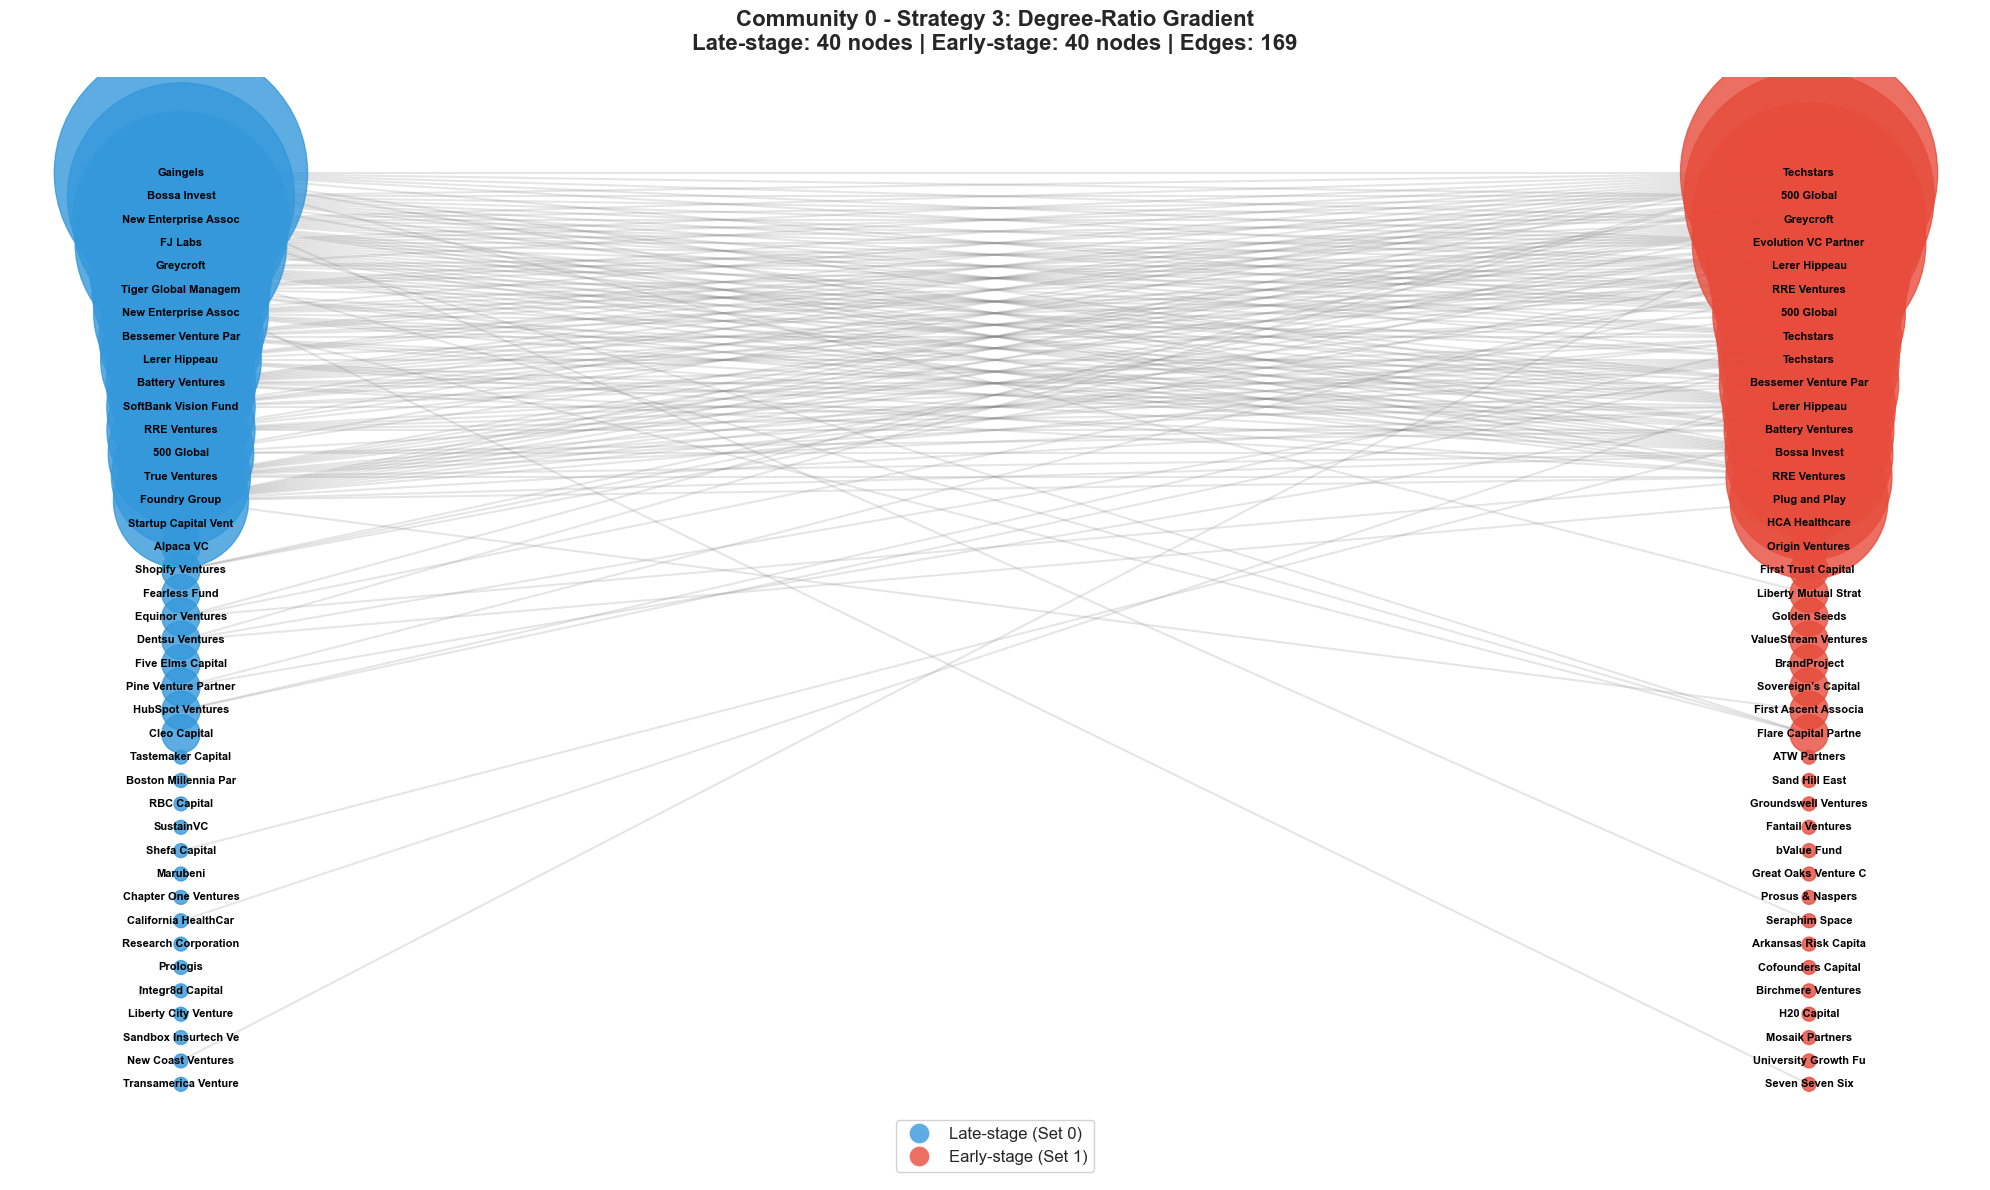



Processing Community 1...
Community 1: Selected 80 nodes across degree spectrum
  Left: high=15, low=15
Selected 80 nodes with 62 edges
Set 0: 40, Set 1: 40


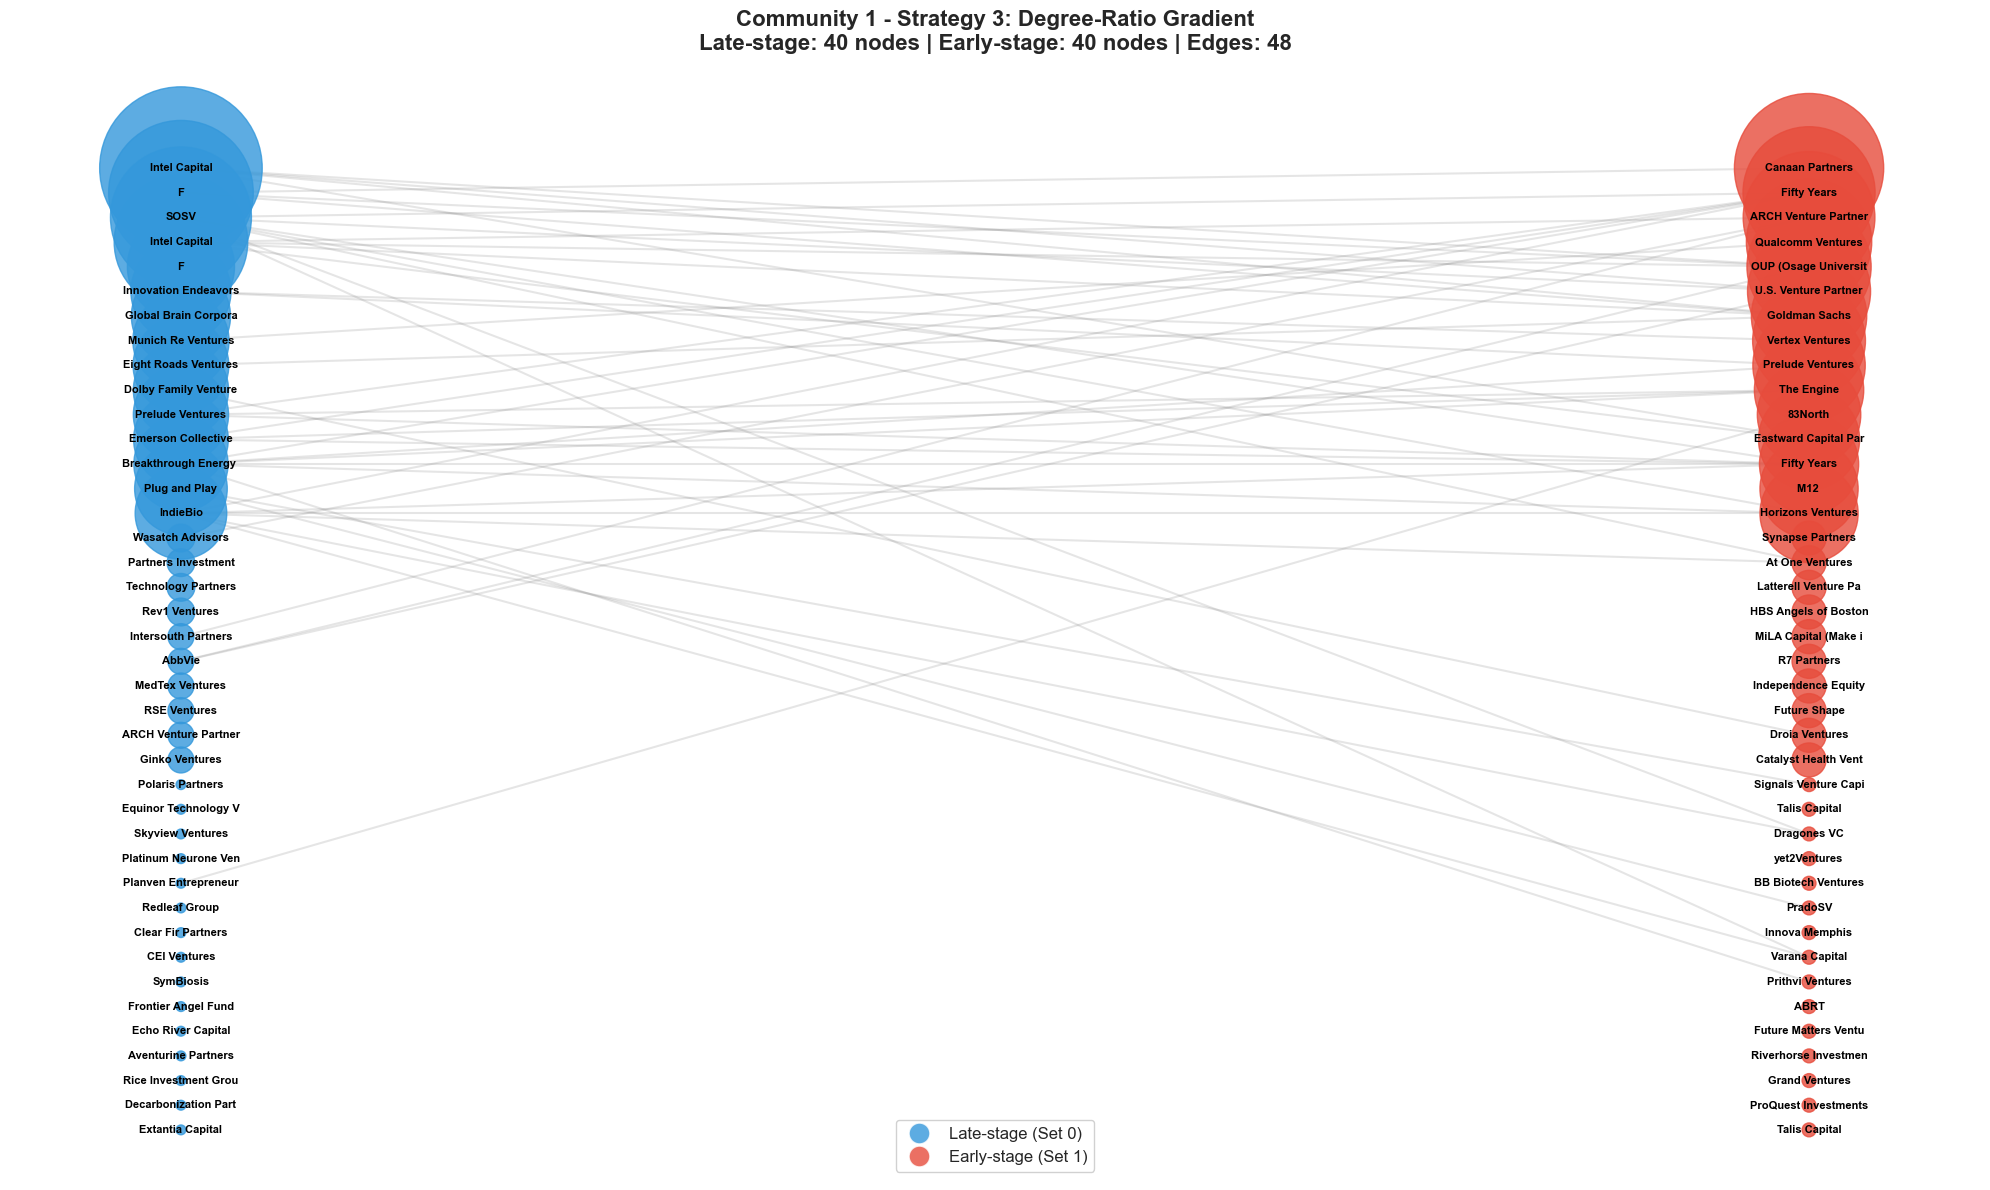



Processing Community 2...
Community 2: Selected 80 nodes across degree spectrum
  Left: high=15, low=15
Selected 80 nodes with 647 edges
Set 0: 40, Set 1: 40


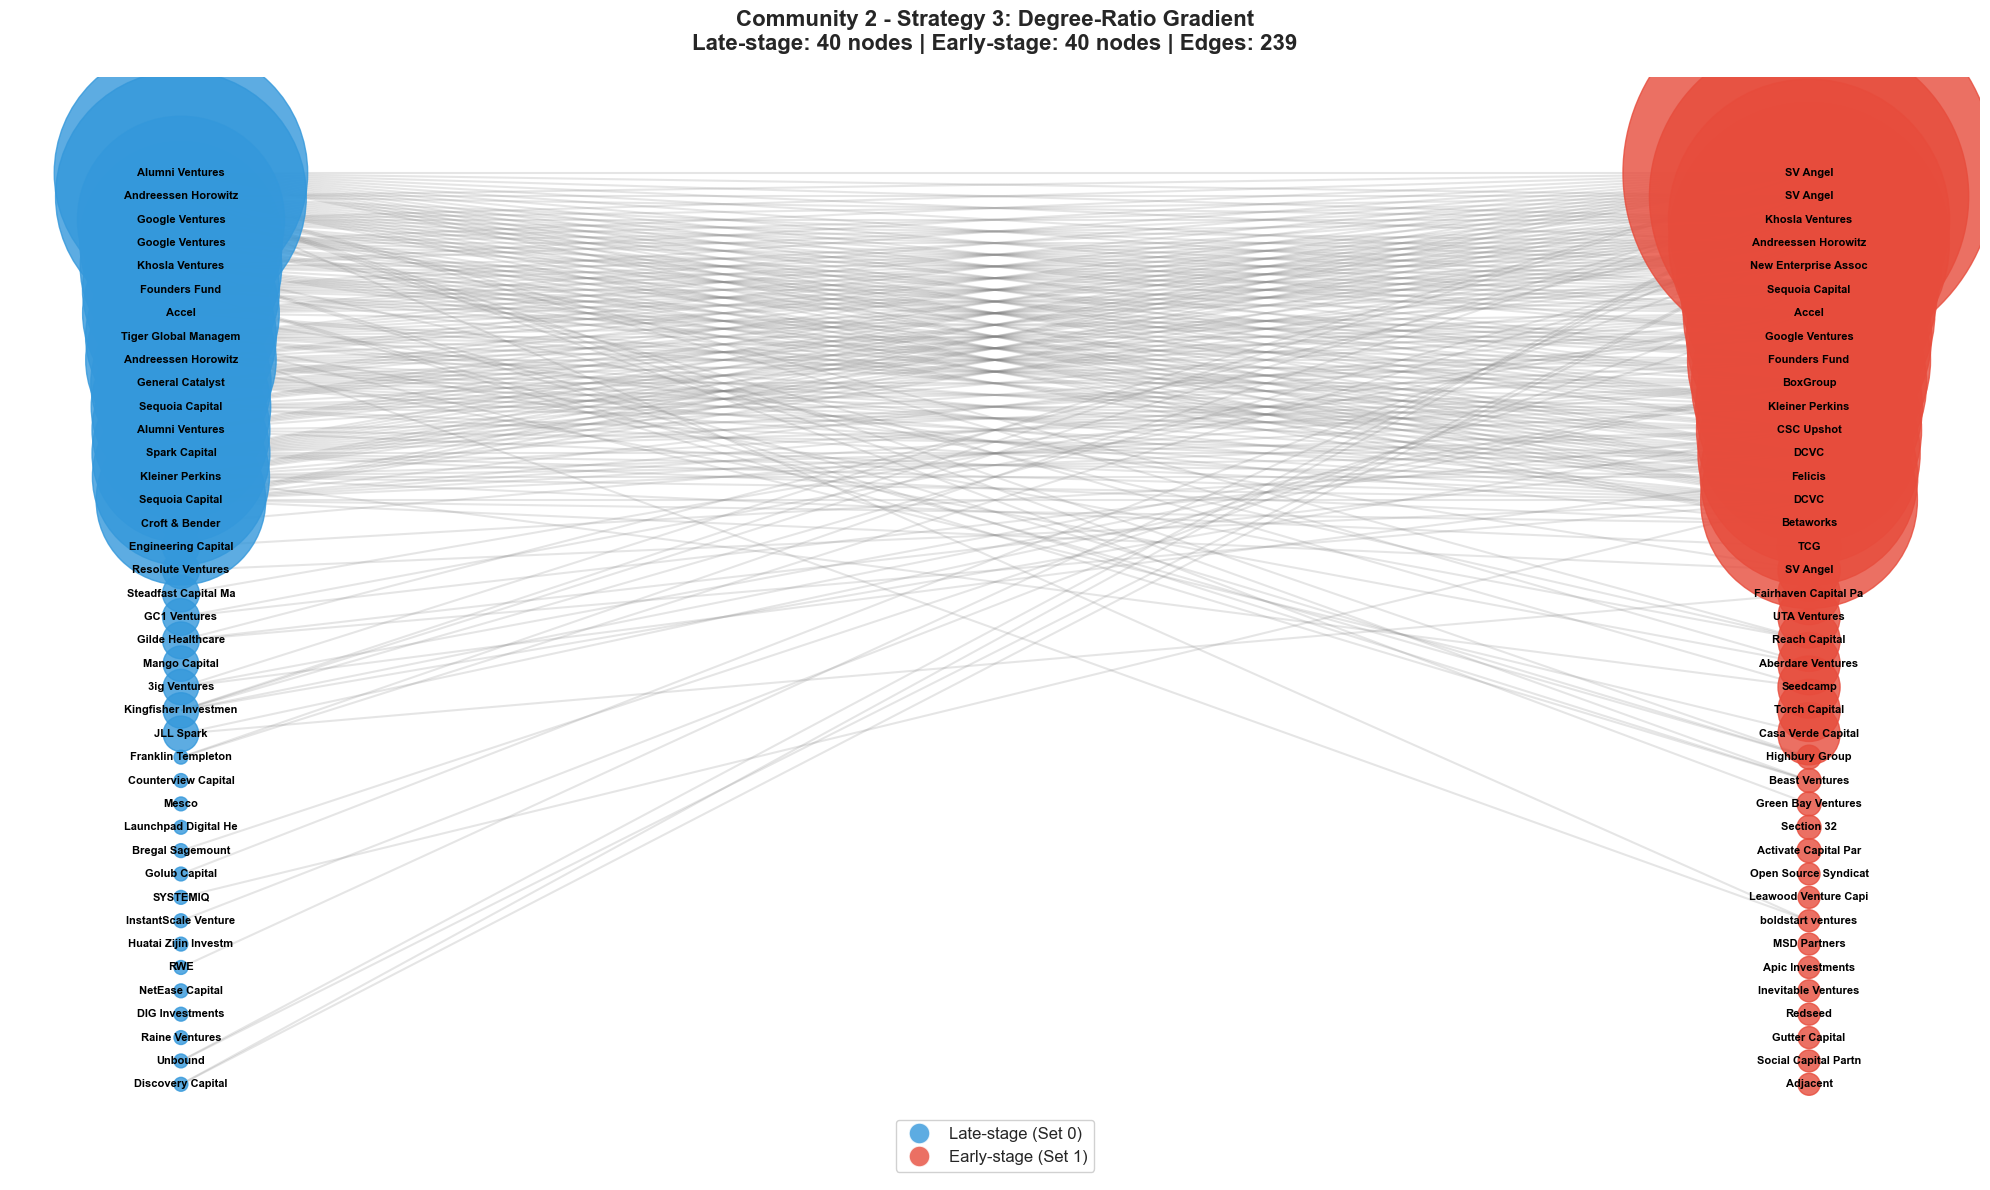

In [10]:
# Apply Strategy 3: Degree-Ratio Filtering
print("="*80)
print("STRATEGY 3: DEGREE-RATIO FILTERING")
print("="*80)

for community_id in target_communities:
    print(f"\nProcessing Community {community_id}...")
    
    # Get nodes using Strategy 3
    selected_nodes = get_degree_ratio_nodes(
        nodes_with_degree, community_id, edges_df,
        n_high=15, n_medium=10, n_low=15
    )
    
    # Get edges between selected nodes
    selected_node_ids = set(selected_nodes['node'].values)
    selected_edges = edges_df[
        (edges_df['Source'].isin(selected_node_ids)) & 
        (edges_df['Target'].isin(selected_node_ids))
    ]
    
    print(f"Selected {len(selected_nodes)} nodes with {len(selected_edges)} edges")
    print(f"Set 0: {(selected_nodes['set'] == 0).sum()}, Set 1: {(selected_nodes['set'] == 1).sum()}")
    
    # Create visualization
    g = create_bipartite_graph(selected_nodes, selected_edges, community_id,
                               "Strategy 3: Degree-Ratio Gradient")
    
    plt.show()
    print()